e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Classes: ['Anthracnose', 'Bacterial_Canker', 'Die_Back', 'Gall_Mid', 'healthy']
Train: 2100  Val: 450  Test: 450
Extracting features...


100%|██████████| 450/450 [01:18<00:00,  5.73it/s]


Feature shapes: Train: (2100, 768) Val: (450, 768) Test: (450, 768)
Epoch 1/50 - Train Loss: 1.9989  Val Loss: 1.8611
Epoch 2/50 - Train Loss: 1.9512  Val Loss: 1.7877
Epoch 3/50 - Train Loss: 1.9293  Val Loss: 1.7488
Epoch 4/50 - Train Loss: 1.9208  Val Loss: 1.7263
Epoch 5/50 - Train Loss: 1.9113  Val Loss: 1.7129
Epoch 6/50 - Train Loss: 1.9064  Val Loss: 1.6995
Epoch 7/50 - Train Loss: 1.8999  Val Loss: 1.6918
Epoch 8/50 - Train Loss: 1.9012  Val Loss: 1.6850
Epoch 9/50 - Train Loss: 1.8953  Val Loss: 1.6819
Epoch 10/50 - Train Loss: 1.8944  Val Loss: 1.6757
Epoch 11/50 - Train Loss: 1.8871  Val Loss: 1.6723
Epoch 12/50 - Train Loss: 1.8890  Val Loss: 1.6698
Epoch 13/50 - Train Loss: 1.8867  Val Loss: 1.6672
Epoch 14/50 - Train Loss: 1.8846  Val Loss: 1.6649
Epoch 15/50 - Train Loss: 1.8837  Val Loss: 1.6620
Epoch 16/50 - Train Loss: 1.8835  Val Loss: 1.6613
Epoch 17/50 - Train Loss: 1.8822  Val Loss: 1.6594
Epoch 18/50 - Train Loss: 1.8819  Val Loss: 1.6578
Epoch 19/50 - Train Los

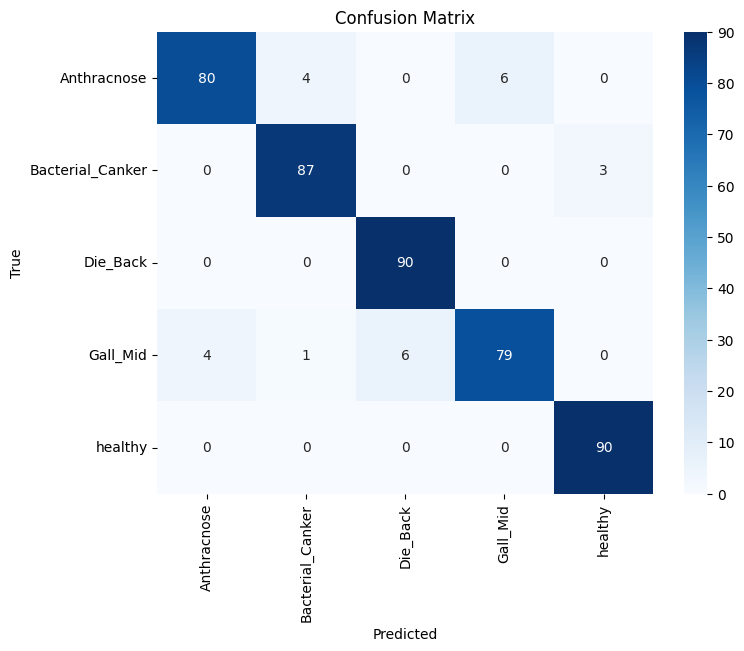

In [1]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# SAM import
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found — add SAM implementation.') from e

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset2"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Dual Augmentation Transforms (tunable)
# =========================
# Hyperparameters you can tune:

ROTATION_DEGREES = 10
HFLIP_PROB = 0.5
VFLIP_PROB = 0.5
COLOR_JITTER1 = 0.2
COLOR_JITTER2 = 0.15
AFFINE_TRANSLATE = 0.1
RESIZEDCROP_SCALE = (0.9, 1)
DUAL_AUG1_PROB = 0.6
DUAL_AUG2_PROB = 0.4

# Base resize
train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]

# First augment: stronger random transforms
dual_aug1 = transforms.RandomApply([
    transforms.RandomChoice([
        transforms.RandomRotation(ROTATION_DEGREES),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ColorJitter(brightness=COLOR_JITTER1, contrast=COLOR_JITTER1, saturation=COLOR_JITTER1),
        transforms.RandomAffine(degrees=0, translate=(AFFINE_TRANSLATE, AFFINE_TRANSLATE))
    ])
], p=DUAL_AUG1_PROB)

# Second augment: mild random crop / flip / jitter
dual_aug2 = transforms.RandomApply([
    transforms.RandomChoice([
        transforms.RandomResizedCrop(IMG_SIZE, scale=RESIZEDCROP_SCALE),
        transforms.RandomVerticalFlip(p=VFLIP_PROB),
        transforms.ColorJitter(brightness=COLOR_JITTER2, contrast=COLOR_JITTER2, saturation=COLOR_JITTER2)
    ])
], p=DUAL_AUG2_PROB)

train_transforms = transforms.Compose(
    train_base + [dual_aug1, dual_aug2, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]
)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transforms) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes: Train:", X_train_feats.shape, "Val:", X_val_feats.shape, "Test:", X_test_feats.shape)

# =========================
# Attention-Guided Mixup
# =========================
def attention_guided_mixup(X, y, mixup_count, alpha=0.5, attention_maps=None):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # keep label of first
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats) * 2  # double the training data
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)
X_final, y_final = X_mix, y_mix

# =========================
# LoRA-adapted ViT Head
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

in_features = X_final.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features=in_features, num_classes=num_classes, dropout_rate=0.4).to(device)

# =========================
# PolyLoss + Label Smoothing
# =========================
class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=0.5, label_smoothing=0.5):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = nn.functional.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = nn.functional.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

criterion = Poly1LossWithSmoothing(num_classes=num_classes, epsilon=0.5, label_smoothing=0.5)

# =========================
# Dataloaders
# =========================
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32),
                                        torch.tensor(y_final, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)

# =========================
# SAM Optimizer + CosineLR
# =========================
base_optimizer = torch.optim.Adam
rho = 0.05
lr = 1e-4
T_max = 50

optimizer = SAM(model_head.parameters(), base_optimizer, rho=rho, lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=T_max)

# =========================
# Training Loop
# =========================
EPOCHS = 50
PATIENCE = 5
best_val_loss = float("inf")
wait = 0
best_model_path = "tinyswin_lora_agmixup_dual_sam.pth"

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # second forward-backward step
        logits2 = model_head(xb)
        loss2 = criterion(logits2, yb)
        loss2.backward()
        optimizer.second_step(zero_grad=True)

        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # Scheduler step
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# =========================
# Evaluation
# =========================
model_head.load_state_dict(torch.load(best_model_path))
model_head.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_head(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print(f"\nTest Metrics (Base + AGM + PolyLoss + LabelSmoothing + DualAug + SAM+CosineLR): "
      f"Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Device: cpu
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600
Extracting features...


100%|██████████| 600/600 [01:11<00:00,  8.35it/s]


Feature shapes: Train: (2800, 768) Val: (600, 768) Test: (600, 768)
Epoch 1/50 - Train Loss: 2.4808  Val Loss: 2.2810
Epoch 2/50 - Train Loss: 2.4018  Val Loss: 2.1662
Epoch 3/50 - Train Loss: 2.3711  Val Loss: 2.1089
Epoch 4/50 - Train Loss: 2.3540  Val Loss: 2.0762
Epoch 5/50 - Train Loss: 2.3451  Val Loss: 2.0546
Epoch 6/50 - Train Loss: 2.3364  Val Loss: 2.0407
Epoch 7/50 - Train Loss: 2.3315  Val Loss: 2.0301
Epoch 8/50 - Train Loss: 2.3291  Val Loss: 2.0226
Epoch 9/50 - Train Loss: 2.3255  Val Loss: 2.0158
Epoch 10/50 - Train Loss: 2.3233  Val Loss: 2.0118
Epoch 11/50 - Train Loss: 2.3191  Val Loss: 2.0065
Epoch 12/50 - Train Loss: 2.3182  Val Loss: 2.0053
Epoch 13/50 - Train Loss: 2.3160  Val Loss: 2.0027
Epoch 14/50 - Train Loss: 2.3132  Val Loss: 2.0004
Epoch 15/50 - Train Loss: 2.3140  Val Loss: 1.9980
Epoch 16/50 - Train Loss: 2.3114  Val Loss: 1.9967
Epoch 17/50 - Train Loss: 2.3102  Val Loss: 1.9943
Epoch 18/50 - Train Loss: 2.3098  Val Loss: 1.9936
Epoch 19/50 - Train Los

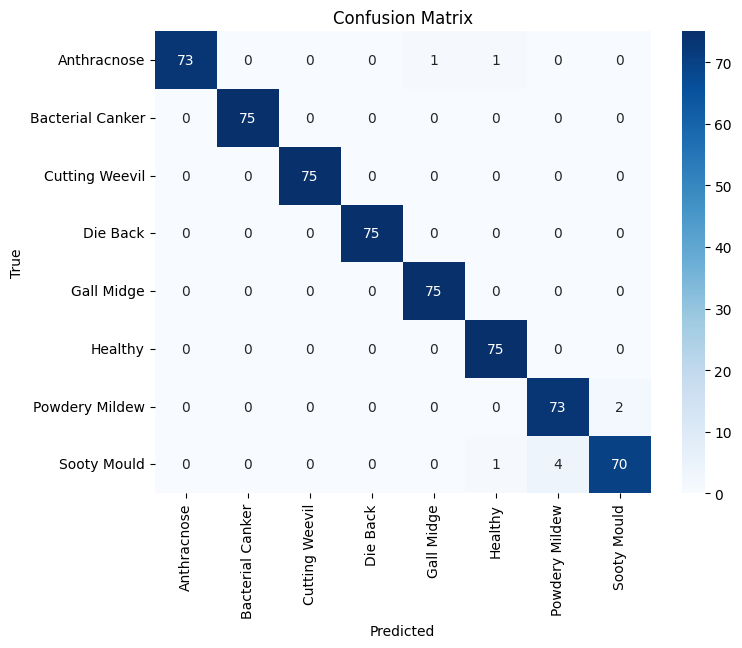

In [2]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# SAM import
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found — add SAM implementation.') from e

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset"
IMG_SIZE = 224

CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Dual Augmentation Transforms (tunable)
# =========================
# Hyperparameters you can tune:

ROTATION_DEGREES = 10
HFLIP_PROB = 0.5
VFLIP_PROB = 0.5
COLOR_JITTER1 = 0.2
COLOR_JITTER2 = 0.15
AFFINE_TRANSLATE = 0.1
RESIZEDCROP_SCALE = (0.9, 1)
DUAL_AUG1_PROB = 0.6
DUAL_AUG2_PROB = 0.4

# Base resize
train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]

# First augment: stronger random transforms
dual_aug1 = transforms.RandomApply([
    transforms.RandomChoice([
        transforms.RandomRotation(ROTATION_DEGREES),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ColorJitter(brightness=COLOR_JITTER1, contrast=COLOR_JITTER1, saturation=COLOR_JITTER1),
        transforms.RandomAffine(degrees=0, translate=(AFFINE_TRANSLATE, AFFINE_TRANSLATE))
    ])
], p=DUAL_AUG1_PROB)

# Second augment: mild random crop / flip / jitter
dual_aug2 = transforms.RandomApply([
    transforms.RandomChoice([
        transforms.RandomResizedCrop(IMG_SIZE, scale=RESIZEDCROP_SCALE),
        transforms.RandomVerticalFlip(p=VFLIP_PROB),
        transforms.ColorJitter(brightness=COLOR_JITTER2, contrast=COLOR_JITTER2, saturation=COLOR_JITTER2)
    ])
], p=DUAL_AUG2_PROB)

train_transforms = transforms.Compose(
    train_base + [dual_aug1, dual_aug2, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)]
)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# Feature Extractor (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transforms) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes: Train:", X_train_feats.shape, "Val:", X_val_feats.shape, "Test:", X_test_feats.shape)

# =========================
# Attention-Guided Mixup
# =========================
def attention_guided_mixup(X, y, mixup_count, alpha=0.5, attention_maps=None):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # keep label of first
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats) * 2  # double the training data
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)
X_final, y_final = X_mix, y_mix

# =========================
# LoRA-adapted ViT Head
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

in_features = X_final.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features=in_features, num_classes=num_classes, dropout_rate=0.4).to(device)

# =========================
# PolyLoss + Label Smoothing
# =========================
class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=0.5, label_smoothing=0.5):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = nn.functional.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = nn.functional.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

criterion = Poly1LossWithSmoothing(num_classes=num_classes, epsilon=0.5, label_smoothing=0.5)

# =========================
# Dataloaders
# =========================
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32),
                                        torch.tensor(y_final, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)

# =========================
# SAM Optimizer + CosineLR
# =========================
base_optimizer = torch.optim.Adam
rho = 0.05
lr = 1e-4
T_max = 50

optimizer = SAM(model_head.parameters(), base_optimizer, rho=rho, lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=T_max)

# =========================
# Training Loop
# =========================
EPOCHS = 50
PATIENCE = 5
best_val_loss = float("inf")
wait = 0
best_model_path = "tinyswin_lora_agmixup_dual_sam.pth"

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # second forward-backward step
        logits2 = model_head(xb)
        loss2 = criterion(logits2, yb)
        loss2.backward()
        optimizer.second_step(zero_grad=True)

        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # Scheduler step
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# =========================
# Evaluation
# =========================
model_head.load_state_dict(torch.load(best_model_path))
model_head.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_head(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print(f"\nTest Metrics (Base + AGM + PolyLoss + LabelSmoothing + DualAug + SAM+CosineLR): "
      f"Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()